STEP 1: Import required libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import ssl

STEP 2: Define Image URL


In [2]:
image_url = "https://drive.google.com/uc?export=download&id=11F2jKq_cUMbNo9-hEDr6WRag7kT7M3oN"

STEP 3: Download Image from URL and Convert to Grayscale

In [3]:
context = ssl._create_unverified_context()
resp = urllib.request.urlopen(image_url, context=context)
image_np = np.asarray(bytearray(resp.read()), dtype=np.uint8)

# Read image as grayscale
gray = cv2.imdecode(image_np, cv2.IMREAD_GRAYSCALE)

if gray is None:
    raise Exception("❌ Failed to load image from the URL.")
else:
    print("✅ Image loaded successfully from Google Drive.")

✅ Image loaded successfully from Google Drive.


STEP 4: Apply Histogram Equalization

    Definition:
    Histogram equalization is a technique for enhancing the contrast of an image.
    It redistributes the intensity values to make the histogram more uniform.

    ➤ Formula:
    new_pixel = round( (cdf(pixel) - cdf_min) / ((M×N) - cdf_min) * (L - 1) )
      where:
        - cdf = cumulative distribution function
        - M×N = total number of pixels
        - L = number of gray levels (usually 256)
        - cdf_min = minimum non-zero value of CDF

In [4]:
# Equalization enhances contrast by spreading intensity values more evenly
equalized = cv2.equalizeHist(gray)

STEP 5: Define Plotting Function

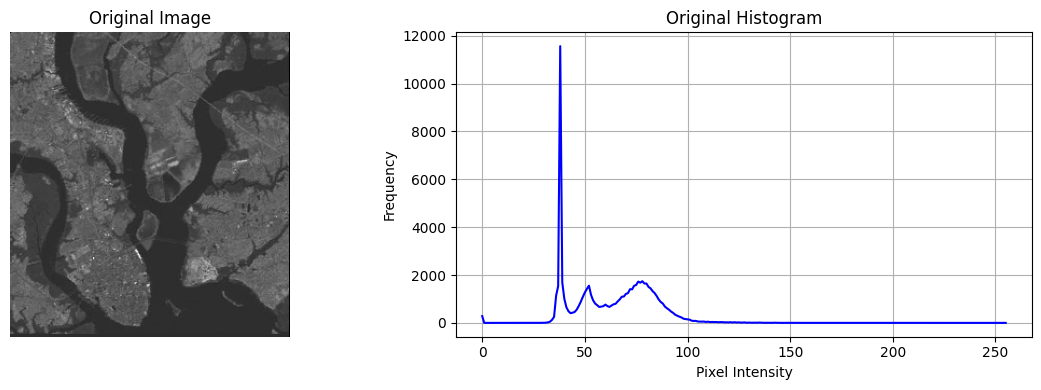

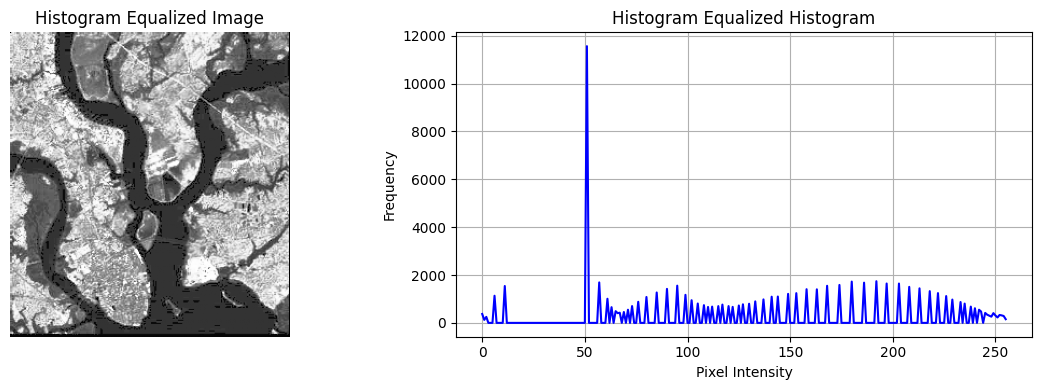

In [5]:
def plot_image_and_histogram(img, title):
    plt.figure(figsize=(12, 4))

    # Show image
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{title} Image")
    plt.axis('off')

    # Show histogram
    plt.subplot(1, 2, 2)
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    plt.plot(hist, color='blue')
    plt.title(f"{title} Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Show Original and Equalized Results

plot_image_and_histogram(gray, "Original")
plot_image_and_histogram(equalized, "Histogram Equalized")